In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import uproot
import pickle
import nue_booster
import importlib
importlib.reload(nue_booster)
import awkward
from typing import List, Tuple, Any, Union
from numpy.typing import NDArray
import hashlib
import logging
import os
import yaml
from numu_tki import selection_1muNp 
from numu_tki import signal_1muNp 
from numu_tki import tki_calculators 

import localSettings as ls

import sys, os 
from data_loading import load_runs

from microfit.selections import get_selection_query

In [3]:
# Load in samples
# RUN = ["5_nuepresel"]
# RUN = ["4a_nuepresel","4b_nuepresel","4c_nuepresel","4d_nuepresel","5_nuepresel"]
# RUN = ["4a_nuepresel_testsplit","4b_nuepresel_testsplit","4c_nuepresel_testsplit","4d_nuepresel_testsplit","5_nuepresel_testsplit"]
# RUN = ["4a_nuepresel_testsplit"]
# RUN = ["4a", "4b", "4c", "4d", "5"]
# RUN = ["5_nuepresel"]
# rundata, mc_weights, data_pot = load_runs(
#     RUN,
#     data="bnb",
#     truth_filtered_sets=["nue", "drt", "nc_pi0"],
#     use_truth_filters=False,
#     loadpi0variables=True,
#     loadshowervariables=True, # Loads in all variables we might want, including BDT variables (use_bdt=True asserts that these variables are loaded)
#     loadrecoveryvars=True,
#     loadsystematics=False,    # Set to false when we don't have event weights
#     load_crt_vars=True,
#     loadnumuvariables=True,
#     use_bdt = False,          # Set use_BDT to false since we are training the BDT here, not using it
#     use_numi=False,
#     load_lee=False,
#     enable_cache=True,
#     blinded=True,             # Set blinded to true, no training on data!!
# )

# Same loading settings as test_bdt.ipynb
# rundata, mc_weights, data_pot = load_runs(
#     RUN,
#     data="bnb",
#     truth_filtered_sets=["nue", "drt", "nc_pi0"],
#     use_truth_filters=False,
#     loadpi0variables=True,
#     loadshowervariables=True,
#     loadrecoveryvars=True,
#     loadsystematics=False,    # Set to false when we don't have event weights
#     load_crt_vars=True,
#     use_bdt = True,
#     load_lee=False,
#     enable_cache=True,
#     blinded=True,
# )

# Load in files that have already been trained on
RUN = ["4a_nuepresel_querysplit","4b_nuepresel_querysplit","4c_nuepresel_querysplit","4d_nuepresel_querysplit","5_nuepresel_querysplit"]
rundata, mc_weights, data_pot = load_runs(
    RUN,
    data="bnb",
    truth_filtered_sets=["nue", "drt", "nc_pi0"],
    use_truth_filters=False,
    loadpi0variables=True,
    loadshowervariables=True,
    loadrecoveryvars=True,
    loadsystematics=False,    # Set to false when we don't have event weights
    load_crt_vars=True,
    use_bdt = True,
    load_lee=False,
    enable_cache=True,
    blinded=True,
)

Loading run 4a_nuepresel_querysplit
Loading run 4b_nuepresel_querysplit
Loading run 4c_nuepresel_querysplit
Loading run 4d_nuepresel_querysplit
Loading run 5_nuepresel_querysplit


In [4]:
df_nu=rundata["mc"]
df_nue=rundata["nue"]
df_dirt=rundata["drt"]
df_ncpi0=rundata["nc_pi0"]
df_ext=rundata["ext"]

In [5]:
# import pandas as pd

# pd.set_option('display.max_rows', None)

# print(df_nu["nu_pdg"])

In [6]:
# print(df_nue["is_signal"])
# print(df_nue["category"])
# print(df_nu)

In [7]:
# Split dataframes into training and testing samples
# train_nu, test_nu = train_test_split(df_nu, test_size=0.5, random_state=1990)
train_nue_truth, test_nue = train_test_split(df_nue, test_size=0.5, random_state=1990)
train_dirt, test_dirt = train_test_split(df_dirt, test_size=0.5, random_state=1990)
train_ncpi0_truth, test_ncpi0 = train_test_split(df_ncpi0, test_size=0.5, random_state=1990)
train_ext, test_ext = train_test_split(df_ext, test_size=0.5, random_state=1990)

In [8]:
# Separate CC Nue events from nu overlay
NUEQUERY = '(abs(nu_pdg)==12 & ccnc==0)'
nu_ccnue = df_nu.query(NUEQUERY)

# Separate NC Pi0 events from nu overlay
NCPI0QUERY = '(mcf_pass_ncpi0==1)'
nu_ncpi0 = df_nu.query(NCPI0QUERY)

# Get sample that doesn't have CC Nue or NC Pi0 events (basically take the opposite of the previous two queries combined)
MCQUERY = '((abs(nu_pdg)==12 & ccnc==0) | mcf_pass_ncpi0==1)'
nu_no_ccnue_ncpi0 = df_nu.query('~'+MCQUERY)

# Split this new nu overlay sample into training and testing samples
train_nu, test_nu = train_test_split(nu_no_ccnue_ncpi0, test_size=0.5, random_state=1990)

# Add CC nue and NC pi0 events into their respective truth training samples
train_nue = pd.concat([train_nue_truth, nu_ccnue], ignore_index=True)
train_ncpi0 = pd.concat([train_ncpi0_truth, nu_ncpi0], ignore_index=True)

In [9]:
# print(nu_ccnue["nu_pdg"])

# print(nu_ncpi0["nu_pdg"])

# print(train_nu["nu_pdg"])

In [10]:
train_nu_25p, test_nu_25p = train_test_split(test_nu, test_size = 0.5, random_state=1990)
# train_nue_25p, test_nue_25p = train_test_split(test_nue, test_size = 0.5, random_state=1990)
train_dirt_25p, test_dirt_25p = train_test_split(test_dirt, test_size = 0.5, random_state=1990)
train_ncpi0_25p, test_ncpi0_25p = train_test_split(test_ncpi0, test_size = 0.5, random_state=1990)
train_ext_25p, test_ext_25p = train_test_split(test_ext, test_size = 0.5, random_state=1990)

In [11]:
SIGNALQUERY = 'category == 10'
BKGQUERY = 'category != 10'

nue_signal = test_nue.query(SIGNALQUERY)
nue_bkg = test_nue.query(BKGQUERY)

train_nue_signal, test_nue_signal = train_test_split(nue_signal, test_size = 0.5, random_state=1990)
train_nue_bkg, test_nue_bkg = train_test_split(nue_bkg, test_size = 0.5, random_state=1990)

In [12]:
print(train_nue_bkg["category"])

35223    11
16963    11
82428     1
75571    11
21690     1
         ..
76656    11
43482    11
36411    11
55569     1
75664    11
Name: category, Length: 76838, dtype: int32


In [13]:
# test_nue.to_csv(os.path.join("/exp/uboone/data/users/kpletcher/slimmedFiles/slimmedMCC910/bdt", "run45_train_nue.csv"), index=False)

In [14]:
# Define set of samples, training and testing all included
# samples = {
#     "mc": (train_nu, test_nu),
#     "nue": (train_nue, test_nue),
#     "dirt": (train_dirt, test_dirt),
#     "ncpi0": (train_ncpi0, test_ncpi0),
#     "ext": (train_ext, test_ext),
# }

# samples = {
#     "mc": (train_nu_25p, test_nu_25p),
#     "nue": (train_nue_25p, test_nue_25p),
#     "dirt": (train_dirt_25p, test_dirt_25p),
#     "ncpi0": (train_ncpi0_25p, test_ncpi0_25p),
#     "ext": (train_ext_25p, test_ext_25p),
# }

samples = {
    "mc": (train_nu_25p, test_nu_25p),
    "nue_signal": (train_nue_signal, test_nue_signal),
    "nue_bkg": (train_nue_bkg, test_nue_bkg),
    "dirt": (train_dirt_25p, test_dirt_25p),
    "ncpi0": (train_ncpi0_25p, test_ncpi0_25p),
    "ext": (train_ext_25p, test_ext_25p),
}

In [15]:
# Set weights for training samples
for k, df in samples.items():
    df[0].loc[:,"train_weight"] = 1.
    df[1].loc[:,"train_weight"] = 1.

# override here train_weight for specific samples, if needed
# QUESTION: are there more specific weights we need here?
samples['ext'][0].loc[:,"train_weight"] = 10.
samples['ext'][1].loc[:,"train_weight"] = 10.

# Set train weight for a specific category (find out what category 4 is)
for k, df in samples.items():
    df[0].loc[df[0]['category']==4,"train_weight"] = 10.
    df[1].loc[df[1]['category']==4,"train_weight"] = 10.

# set train_weight based on reco_e binning
# reco_bins = np.linspace(0.15,1.55,15)
# #reco_scaling = [8,5,3,3,2,2,2,1,1,1,1,1,1,1]
# reco_scaling = [1,1,1,1,1,1,1,1,1,1,1,1,1,1]
# for k, df in samples.items():
#     for i, reco_bin in enumerate(reco_bins):
#         if i == 0: continue
#         df[0].loc[(df[0]['reco_e'] > reco_bins[i-1]) & (df[0]['reco_e'] < reco_bins[i]), 'train_weight'] = df[0]['train_weight']*reco_scaling[i-1]

In [16]:
# Inclusive set of variables w/ NuGraph
# TRAINVAR = [
#     "shrmoliereavg",
#     "shr_score",
#     "trkfit",
#     "subcluster",
#     "CosmicIPAll3D",
#     "CosmicDirAll3D",
#     "shrMCSMom",
#     "DeltaRMS2h",
#     "shrPCA1CMed_5cm",
#     "CylFrac2h_1cm",    
#     "shr_tkfit_2cm_dedx_Y",
#     "shr_tkfit_2cm_dedx_U",
#     "shr_tkfit_2cm_dedx_V",
#     "shr_tkfit_gap10_dedx_Y",
#     "shr_tkfit_gap10_dedx_U",
#     "shr_tkfit_gap10_dedx_V",
#     "shr_tkfit_dedx_max",
#     "secondshower_U_nhit",
#     "secondshower_U_vtxdist",
#     "secondshower_U_dot",
#     "secondshower_U_dir",
#     "anglediff_U",
#     "secondshower_V_nhit",
#     "secondshower_V_vtxdist",
#     "secondshower_V_dot",
#     "secondshower_V_dir",
#     "anglediff_V",
#     "secondshower_Y_nhit",
#     "secondshower_Y_vtxdist",
#     "secondshower_Y_dot",
#     "secondshower_Y_dir",
#     "anglediff_Y",
#     "slcng2mip",
#     "slcng2hip",
#     "slcng2shr",
#     "slcng2mcl",
#     "slcng2dfs",
#     "slcng2bkg",
#     "clung2mip",
#     "clung2hip",
#     "clung2shr",
#     "clung2mcl",
#     "clung2dfs",
#     "clung2bkg",
#     "nhits_r1cm",
#     "nhits_r3cm",
#     "nhits_r5cm",
#     "nhits_r10cm",
#     "diffY","normdiffY","diffZ","normdiffZ","fnl",
#     "is_signal","train_weight","nu_e"
# ]

TRAINVAR = [
    "shrmoliereavg",
    "shr_score",
    "trkfit",
    "subcluster",
    "CosmicIPAll3D",
    "CosmicDirAll3D",
    "shrMCSMom",
    "DeltaRMS2h",
    "shrPCA1CMed_5cm",
    "CylFrac2h_1cm",    
    "shr_tkfit_2cm_dedx_Y",
    "shr_tkfit_2cm_dedx_U",
    "shr_tkfit_2cm_dedx_V",
    "shr_tkfit_gap10_dedx_Y",
    "shr_tkfit_gap10_dedx_U",
    "shr_tkfit_gap10_dedx_V",
    # "shr_tkfit_dedx_U",
    # "shr_tkfit_dedx_V",
    # "shr_tkfit_dedx_Y",
    "shr_tkfit_dedx_max",
    "secondshower_U_nhit",
    "secondshower_U_vtxdist",
    "secondshower_U_dot",
    "secondshower_U_dir",
    "anglediff_U",
    "secondshower_V_nhit",
    "secondshower_V_vtxdist",
    "secondshower_V_dot",
    "secondshower_V_dir",
    "anglediff_V",
    "secondshower_Y_nhit",
    "secondshower_Y_vtxdist",
    "secondshower_Y_dot",
    "secondshower_Y_dir",
    "anglediff_Y",
    "slcng2mip",
    "slcng2hip",
    "slcng2shr",
    "slcng2mcl",
    "slcng2dfs",
    "slcng2bkg",
    "clung2mip",
    "clung2hip",
    "clung2shr",
    "clung2mcl",
    "clung2dfs",
    "clung2bkg",
    "nhits_r1cm",
    "nhits_r3cm",
    "nhits_r5cm",
    "nhits_r10cm",
    "diffY","normdiffY","diffZ","normdiffZ","fnl",
    "is_signal","train_weight","nu_e"
]

# Np Training Variables
# TRAINVAR = [
#     "shr_score",
#     "tksh_distance",
#     "tksh_angle",
#     "shr_tkfit_2cm_dedx_Y",
#     "shr_tkfit_2cm_dedx_U",
#     "shr_tkfit_2cm_dedx_V",
#     "shr_tkfit_gap10_dedx_Y",
#     "shr_tkfit_gap10_dedx_U",
#     "shr_tkfit_gap10_dedx_V",
#     "shr_tkfit_dedx_max",
#     "trkfit",
#     "trkpid",
#     "subcluster",
#     "shrmoliereavg",
#     "trkshrhitdist2",
#     "hits_ratio",
#     "CosmicIPAll3D",
#     "CosmicDirAll3D",
#     "secondshower_U_nhit",
#     "secondshower_U_vtxdist",
#     "secondshower_U_dot",
#     "secondshower_U_dir",
#     "anglediff_U",
#     "secondshower_V_nhit",
#     "secondshower_V_vtxdist",
#     "secondshower_V_dot",
#     "secondshower_V_dir",
#     "anglediff_V",
#     "secondshower_Y_nhit",
#     "secondshower_Y_vtxdist",
#     "secondshower_Y_dot",
#     "secondshower_Y_dir",
#     "anglediff_Y",
#     "slcng2mip",
#     "slcng2hip",
#     "slcng2shr",
#     "slcng2mcl",
#     "slcng2dfs",
#     "slcng2bkg",
#     "clung2mip",
#     "clung2hip",
#     "clung2shr",
#     "clung2mcl",
#     "clung2dfs",
#     "clung2bkg",
#     "nhits_r1cm",
#     "nhits_r3cm",
#     "nhits_r5cm",
#     "nhits_r10cm",
#     "diffY","normdiffY","diffZ","normdiffZ","fnl",
#     "is_signal","train_weight","nu_e"
# ]

In [17]:
# print (ls.pickle_path)

XGBoost params. ETA: 0.02, MAX_DEPTH: 3, SUBSAMPLE: 0.8, COLSAMPLE_BY_TREE: 1
['shrmoliereavg', 'shr_score', 'trkfit', 'subcluster', 'CosmicIPAll3D', 'CosmicDirAll3D', 'shrMCSMom', 'DeltaRMS2h', 'shrPCA1CMed_5cm', 'CylFrac2h_1cm', 'shr_tkfit_2cm_dedx_Y', 'shr_tkfit_2cm_dedx_U', 'shr_tkfit_2cm_dedx_V', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_gap10_dedx_U', 'shr_tkfit_gap10_dedx_V', 'shr_tkfit_dedx_max', 'secondshower_U_nhit', 'secondshower_U_vtxdist', 'secondshower_U_dot', 'secondshower_U_dir', 'anglediff_U', 'secondshower_V_nhit', 'secondshower_V_vtxdist', 'secondshower_V_dot', 'secondshower_V_dir', 'anglediff_V', 'secondshower_Y_nhit', 'secondshower_Y_vtxdist', 'secondshower_Y_dot', 'secondshower_Y_dir', 'anglediff_Y', 'slcng2mip', 'slcng2hip', 'slcng2shr', 'slcng2mcl', 'slcng2dfs', 'slcng2bkg', 'clung2mip', 'clung2hip', 'clung2shr', 'clung2mcl', 'clung2dfs', 'clung2bkg', 'nhits_r1cm', 'nhits_r3cm', 'nhits_r5cm', 'nhits_r10cm', 'diffY', 'normdiffY', 'diffZ', 'normdiffZ', 'fnl', 'is_signa

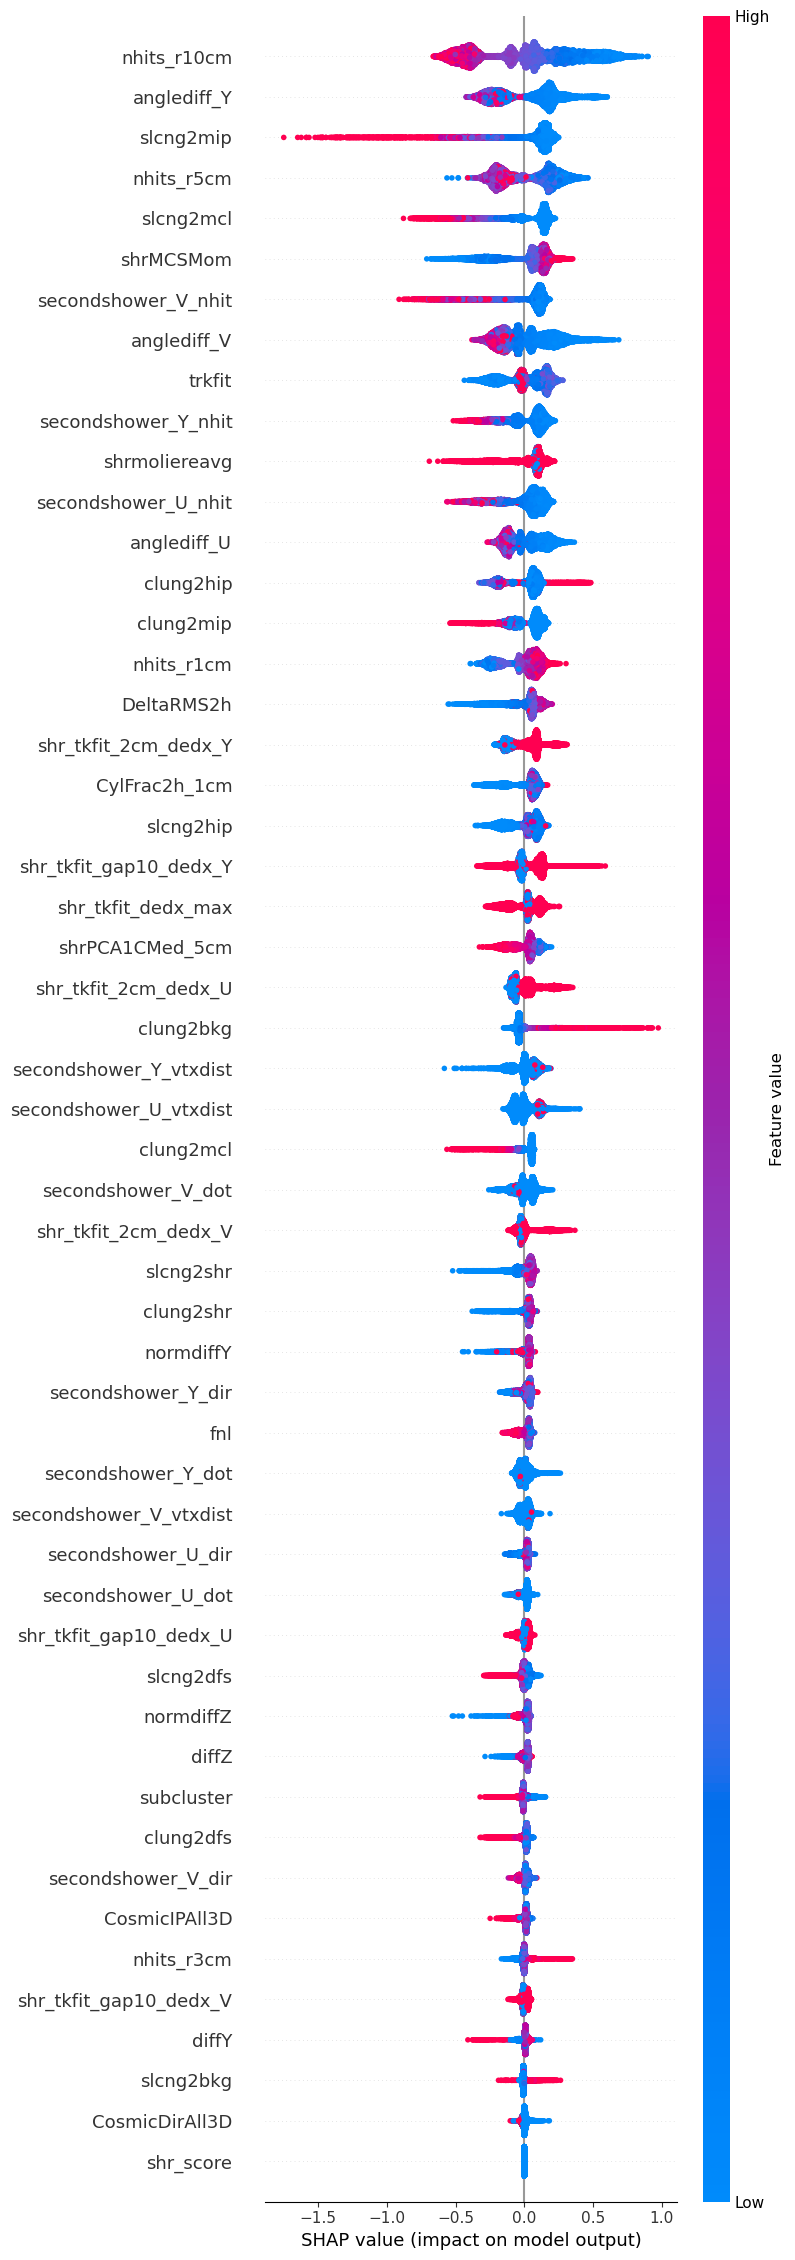

area under the precision-recall curve: 0.934472
precision score: 0.828403
recall score: 0.931193
Importance (total_gain):
nhits_r10cm 18189.411163349992
slcng2mip 14219.85970603399
nhits_r5cm 10803.958827690014
slcng2mcl 10290.846397300009
anglediff_Y 8972.278241479997
shrMCSMom 7635.922084833006
secondshower_V_nhit 6963.059459411997
anglediff_V 5526.681480790004
clung2mip 4447.480632619998
trkfit 4382.3407442200005
secondshower_U_nhit 4176.624075768101
shrmoliereavg 4067.818366351
shr_tkfit_2cm_dedx_Y 4009.000605700002
shr_tkfit_gap10_dedx_Y 3780.2190358899984
secondshower_Y_nhit 3601.4621720899963
DeltaRMS2h 3534.258537340001
CylFrac2h_1cm 3297.5040405569985
anglediff_U 3211.4678681700025
secondshower_Y_vtxdist 3003.257619710001
shr_tkfit_dedx_max 2847.019009750001
clung2hip 2724.0776947200015
clung2shr 2625.2729729800003
slcng2hip 2487.57850523
clung2bkg 2470.8588658599997
nhits_r1cm 2412.4129797900014
clung2mcl 2306.717618098999
secondshower_U_vtxdist 2270.333319009999
shrPCA1CMed_

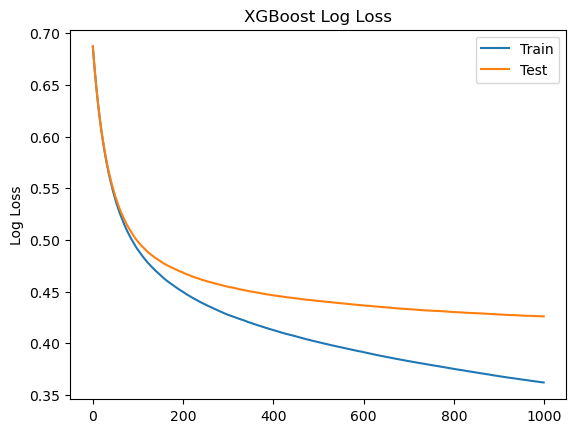

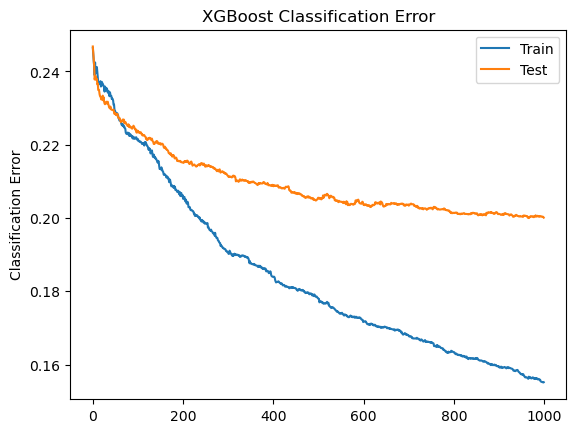

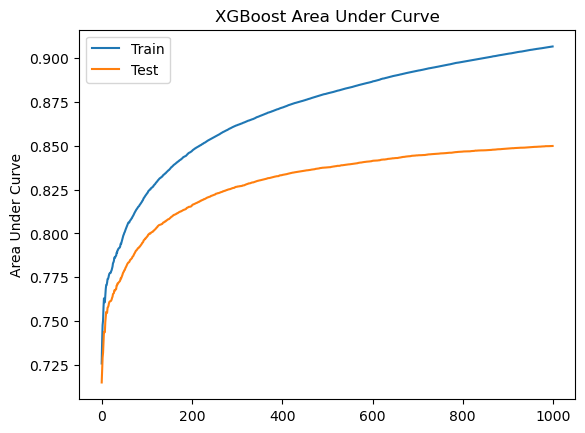

In [18]:
fig, ax = plt.subplots(1,1)

importlib.reload(nue_booster)
my_booster = nue_booster.NueBooster(samples, TRAINVAR, random_state=1990)

print (my_booster.variables)

# Nue Preselection
# PRESEL = 'slice_orig_pass_id == 1'
# PRESEL += ' and n_showers_contained == 1'
# PRESEL += ' and contained_fraction > 0.9'
# PRESEL += ' and shr_energy_tot_cali > 0.07'
# PRESEL += ' and ( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'

# Extra Cosmic Rejection
# PRESEL += ' and CosmicIPAll3D > 10.'
# PRESEL += ' and trkfit < 0.65'

PRESEL = '( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'
PRESEL += ' and n_tracks_contained == 0'

PRESEL += ' and crtveto != 1'

PRESEL += ' and CosmicIPAll3D > 10.'
PRESEL += ' and shrmoliereavg < 20'
PRESEL += ' and subcluster > 5'
PRESEL += ' and shr_trk_sce_start_y > -100 and shr_trk_sce_start_y < 100'
PRESEL += ' and shr_trk_len > 20'
PRESEL += ' and CylFrac2h_1cm < 0.7'
PRESEL += ' and shrMCSMom > 20'
PRESEL += ' and (n_tracks_tot == 0 or (n_tracks_tot>0 and tk1sh1_angle_alltk>-0.9))'

PRESEL += ' and diffZ > -70 and diffZ < 80'
PRESEL += ' and normdiffZ > -0.75 and normdiffZ < 0.75'
PRESEL += ' and fnl > -200 and fnl < 50'

PRESEL += ' and nonpi0_score > 0.6'
PRESEL += ' and pi0_score > 0.4'

# PRESEL += ' and slcng2hip < 40'
# PRESEL += ' and slcng2mip < 50'
# PRESEL += ' and slcng2mcl < 40'
# PRESEL += ' and clung2hip < 50'

# Old Loose Sel.
# PRESEL = '( (_opfilter_pe_beam > 0 and _opfilter_pe_veto < 20) or bnbdata == 1 or extdata == 1)'
# PRESEL += ' and n_tracks_contained == 0'
# PRESEL += ' and CosmicIPAll3D > 10.'
# PRESEL += ' and CosmicDirAll3D > -0.9 and CosmicDirAll3D < 0.9'
# PRESEL += ' and shrmoliereavg < 15'
# PRESEL += ' and subcluster > 4'
# PRESEL += ' and trkfit < 0.65'
# PRESEL += ' and secondshower_Y_nhit < 50'
# PRESEL += ' and shr_trk_sce_start_y > -100 and shr_trk_sce_start_y < 80'
# PRESEL += ' and shr_trk_sce_end_y > -100 and shr_trk_sce_end_y < 100 '
# PRESEL += ' and shr_trk_len < 300.'
# PRESEL += ' and (n_tracks_tot == 0 or (n_tracks_tot>0 and tk1sh1_angle_alltk>-0.9))'

my_booster.set_preselection(PRESEL)

gain_imp = {}

for label, bkg_query in zip(nue_booster.labels, nue_booster.bkg_queries):
    
    preds, gain_imp[label], evals_result, shap_values = my_booster.train_booster(ax, bkg_query)
    
    with open(ls.pickle_path+'booster_%s_45_1011_0pnewloosesel_stackedNpBkg.pickle' % label, 'wb') as booster_file:
        pickle.dump(preds, booster_file)

    #print(evals_result)
    epochs = len(evals_result['train']['error'])
    x_axis = range(0, epochs)
    # plot log loss
    fig1, ax1 = plt.subplots()
    ax1.plot(x_axis, evals_result['train']['logloss'], label='Train')
    ax1.plot(x_axis, evals_result['eval']['logloss'], label='Test')
    ax1.legend()
    plt.ylabel('Log Loss')
    plt.title('XGBoost Log Loss')
    plt.show()
    # plot classification error
    fig2, ax2 = plt.subplots()
    ax2.plot(x_axis, evals_result['train']['error'], label='Train')
    ax2.plot(x_axis, evals_result['eval']['error'], label='Test')
    ax2.legend()
    plt.ylabel('Classification Error')
    plt.title('XGBoost Classification Error')
    plt.show()
    # plot auc
    fig3, ax3 = plt.subplots()
    ax3.plot(x_axis, evals_result['train']['auc'], label='Train')
    ax3.plot(x_axis, evals_result['eval']['auc'], label='Test')
    ax3.legend()
    plt.ylabel('Area Under Curve')
    plt.title('XGBoost Area Under Curve')
    plt.show()

    
ax.set_ylim([0, 1.05])
ax.set_xlim([0, 1.0])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC')
ax.legend()
fig.tight_layout()
#fig.savefig(ls.plots_path+"roc_single.pdf")

In [19]:
print('mc',train_nu.query(PRESEL)["train_weight"].sum())
print('nue',train_nue.query(PRESEL)["train_weight"].sum())
print('dirt',train_dirt.query(PRESEL)["train_weight"].sum())
print('ncpi0',train_ncpi0.query(PRESEL)["train_weight"].sum())
print('ext',train_ext.query(PRESEL)["train_weight"].sum())

# print('mc',train_nu_25p.query(PRESEL)["train_weight"].sum())
# print('nue',train_nue_25p.query(PRESEL)["train_weight"].sum())
# print('dirt',train_dirt_25p.query(PRESEL)["train_weight"].sum())
# print('ncpi0',train_ncpi0_25p.query(PRESEL)["train_weight"].sum())
# print('ext',train_ext_25p.query(PRESEL)["train_weight"].sum())

KeyError: 'train_weight'

In [ ]:
print('mc',test_nu.query(PRESEL)["train_weight"].sum())
print('nue',test_nue.query(PRESEL)["train_weight"].sum())
print('dirt',test_dirt.query(PRESEL)["train_weight"].sum())
print('ncpi0',test_ncpi0.query(PRESEL)["train_weight"].sum())
print('ext',test_ext.query(PRESEL)["train_weight"].sum())

# print('mc',test_nu_25p.query(PRESEL)["train_weight"].sum())
# print('nue',test_nue_25p.query(PRESEL)["train_weight"].sum())
# print('dirt',test_dirt_25p.query(PRESEL)["train_weight"].sum())
# print('ncpi0',test_ncpi0_25p.query(PRESEL)["train_weight"].sum())
# print('ext',test_ext_25p.query(PRESEL)["train_weight"].sum())

mc 699.0
nue 30254.0
dirt 22.0
ncpi0 8046.0
ext 3320.0


In [20]:
print(gain_imp['pi0'])
print(gain_imp['nonpi0'])
print(gain_imp['bkg'])

if 'shr_tkfit_gap10_dedx_V' in gain_imp['pi0']:
    gain_imp['pi0']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['pi0']['shr_tkfit_gap10_dedx_V']+gain_imp['pi0']['shr_tkfit_gap10_dedx_U']+gain_imp['pi0']['shr_tkfit_gap10_dedx_Y']
    gain_imp['nonpi0']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['nonpi0']['shr_tkfit_gap10_dedx_V']+gain_imp['nonpi0']['shr_tkfit_gap10_dedx_U']+gain_imp['nonpi0']['shr_tkfit_gap10_dedx_Y']
    gain_imp['bkg']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['bkg']['shr_tkfit_gap10_dedx_V']+gain_imp['bkg']['shr_tkfit_gap10_dedx_U']+gain_imp['bkg']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['pi0']['shr_tkfit_gap10_dedx_V']
    del gain_imp['pi0']['shr_tkfit_gap10_dedx_U']
    del gain_imp['pi0']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['nonpi0']['shr_tkfit_gap10_dedx_V']
    del gain_imp['nonpi0']['shr_tkfit_gap10_dedx_U']
    del gain_imp['nonpi0']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['bkg']['shr_tkfit_gap10_dedx_V']
    del gain_imp['bkg']['shr_tkfit_gap10_dedx_U']
    del gain_imp['bkg']['shr_tkfit_gap10_dedx_Y']
if 'shr_tkfit_2cm_dedx_V' in gain_imp['pi0']:
    gain_imp['pi0']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['pi0']['shr_tkfit_2cm_dedx_V']+gain_imp['pi0']['shr_tkfit_2cm_dedx_U']+gain_imp['pi0']['shr_tkfit_2cm_dedx_Y']
    gain_imp['nonpi0']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['nonpi0']['shr_tkfit_2cm_dedx_V']+gain_imp['nonpi0']['shr_tkfit_2cm_dedx_U']+gain_imp['nonpi0']['shr_tkfit_2cm_dedx_Y']
    gain_imp['bkg']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['bkg']['shr_tkfit_2cm_dedx_V']+gain_imp['bkg']['shr_tkfit_2cm_dedx_U']+gain_imp['bkg']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['pi0']['shr_tkfit_2cm_dedx_V']
    del gain_imp['pi0']['shr_tkfit_2cm_dedx_U']
    del gain_imp['pi0']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['nonpi0']['shr_tkfit_2cm_dedx_V']
    del gain_imp['nonpi0']['shr_tkfit_2cm_dedx_U']
    del gain_imp['nonpi0']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['bkg']['shr_tkfit_2cm_dedx_V']
    del gain_imp['bkg']['shr_tkfit_2cm_dedx_U']
    del gain_imp['bkg']['shr_tkfit_2cm_dedx_Y']

print(gain_imp['bkg'])
# print(gain_imp['bkg']['shr_tkfit_2cm_dedx_ALL'])

labels = []
pi0_imp = []
nonpi0_imp = []
bkg_imp = []

for i in sorted (gain_imp['pi0'].keys()) :  
    labels.append(i)
    pi0_imp.append(gain_imp['pi0'][i])
    nonpi0_imp.append(gain_imp['nonpi0'][i])
    bkg_imp.append(gain_imp['bkg'][i])
    
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width, pi0_imp, width, label='pi0', color='deepskyblue')
rects2 = ax.bar(x, nonpi0_imp, width, label='nonpi0', color='yellowgreen')
rects3 = ax.bar(x + width, bkg_imp, width, label='bkg', color='darkmagenta')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('total gain')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_gain.pdf")
#fig.savefig(ls.plots_path+"bdt_var_gain.pdf")

KeyError: 'pi0'

{'nhits_r10cm': 18189.411163349992, 'slcng2mcl': 10290.846397300009, 'anglediff_Y': 8972.278241479997, 'slcng2mip': 14219.85970603399, 'secondshower_V_nhit': 6963.059459411997, 'clung2mip': 4447.480632619998, 'shr_tkfit_dedx_max': 2847.019009750001, 'shrMCSMom': 7635.922084833006, 'anglediff_U': 3211.4678681700025, 'CylFrac2h_1cm': 3297.5040405569985, 'clung2mcl': 2306.717618098999, 'shrPCA1CMed_5cm': 2247.3329924361988, 'nhits_r5cm': 10803.958827690014, 'shrmoliereavg': 4067.818366351, 'clung2shr': 2625.2729729800003, 'secondshower_Y_dir': 2036.828023860001, 'shr_tkfit_gap10_dedx_V': 796.52465797, 'secondshower_U_nhit': 4176.624075768101, 'DeltaRMS2h': 3534.258537340001, 'subcluster': 1315.7168041900004, 'slcng2bkg': 714.3292334099998, 'clung2bkg': 2470.8588658599997, 'secondshower_Y_vtxdist': 3003.257619710001, 'shr_tkfit_2cm_dedx_U': 2208.7139889164996, 'secondshower_Y_nhit': 3601.4621720899963, 'anglediff_V': 5526.681480790004, 'shr_tkfit_2cm_dedx_Y': 4009.000605700002, 'shr_tkfit_

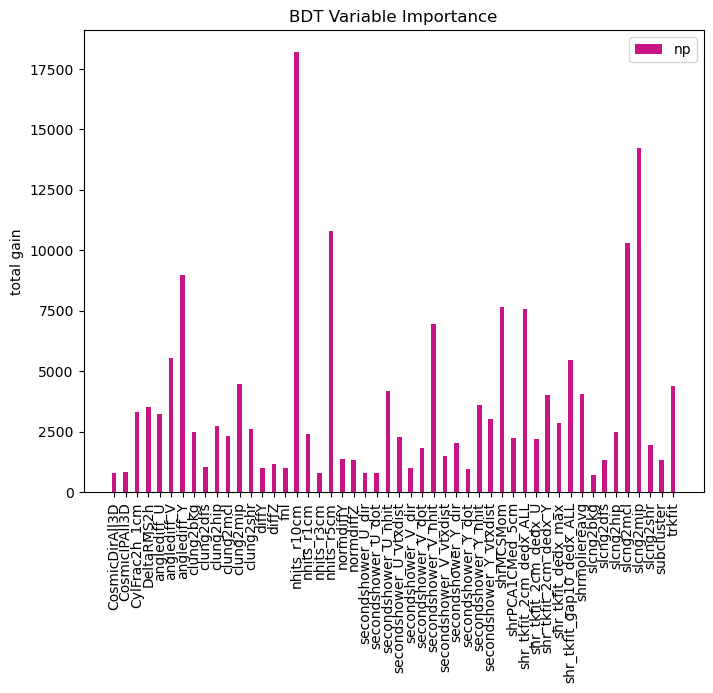

In [24]:
print(gain_imp['np'])

if 'shr_tkfit_gap10_dedx_V' in gain_imp['np']:
    gain_imp['np']['shr_tkfit_gap10_dedx_ALL'] = gain_imp['np']['shr_tkfit_gap10_dedx_V']+gain_imp['np']['shr_tkfit_gap10_dedx_U']+gain_imp['np']['shr_tkfit_gap10_dedx_Y']
    del gain_imp['np']['shr_tkfit_gap10_dedx_V']
    del gain_imp['np']['shr_tkfit_gap10_dedx_U']
    del gain_imp['np']['shr_tkfit_gap10_dedx_Y']
if 'shr_tkfit_2cm_dedx_V' in gain_imp['np']:
    gain_imp['np']['shr_tkfit_2cm_dedx_ALL'] = gain_imp['np']['shr_tkfit_2cm_dedx_V']+gain_imp['np']['shr_tkfit_2cm_dedx_U']+gain_imp['np']['shr_tkfit_2cm_dedx_Y']
    del gain_imp['np']['shr_tkfit_2cm_dedx_V']

print(gain_imp['np'])
# print(gain_imp['bkg']['shr_tkfit_2cm_dedx_ALL'])

labels = []
np_imp = []

for i in sorted (gain_imp['np'].keys()) :  
    labels.append(i)
    np_imp.append(gain_imp['np'][i])
    
x = np.arange(len(labels))  # the label locations
width = 0.4  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects2 = ax.bar(x, np_imp, width, label='np', color='mediumvioletred')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('total gain')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_gain.pdf")
#fig.savefig(ls.plots_path+"bdt_var_gain.pdf")

In [22]:
d_pi0_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['pi0'], key=gain_imp['pi0'].get, reverse=True):
    d_pi0_rnk[w] = rnk
    rnk = rnk-1
print(d_pi0_rnk)

d_nonpi0_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['nonpi0'], key=gain_imp['nonpi0'].get, reverse=True):
    d_nonpi0_rnk[w] = rnk
    rnk = rnk-1
print(d_nonpi0_rnk)

d_bkg_rnk = {}
rnk = len(labels)
for w in sorted(gain_imp['bkg'], key=gain_imp['bkg'].get, reverse=True):
    d_bkg_rnk[w] = rnk
    rnk = rnk-1
print(d_bkg_rnk)

pi0_rnk = []
nonpi0_rnk = []
bkg_rnk = []

for i in labels:  
    pi0_rnk.append(d_pi0_rnk[i])
    nonpi0_rnk.append(d_nonpi0_rnk[i])
    bkg_rnk.append(d_bkg_rnk[i])
    
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8,6))
rects1 = ax.bar(x - width, pi0_rnk, width, label='pi0', color='deepskyblue')
rects2 = ax.bar(x, nonpi0_rnk, width, label='nonpi0', color='yellowgreen')
rects3 = ax.bar(x + width, bkg_rnk, width, label='bkg', color='darkmagenta')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Rank (based on total gain)')
ax.set_title('BDT Variable Importance')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation = 90)
ax.legend()

plt.show()
fig.tight_layout()
#fig.savefig(ls.plots_path+"0109/bdt_var_rank.pdf")
#fig.savefig(ls.plots_path+"bdt_var_rank.pdf")

NameError: name 'labels' is not defined

In [23]:
# d_np_rnk = {}
# rnk = len(labels)
# for w in sorted(gain_imp['np'], key=gain_imp['np'].get, reverse=True):
#     d_np_rnk[w] = rnk
#     rnk = rnk-1
# print(d_np_rnk)

# np_rnk = []

# for i in labels:  
#     np_rnk.append(d_np_rnk[i])
    
# x = np.arange(len(labels))  # the label locations
# width = 0.4  # the width of the bars

# fig, ax = plt.subplots(figsize=(8,6))
# rects1 = ax.bar(x - width, np_rnk, width, label='np', color='cornflowerblue')

# # Add some text for labels, title and custom x-axis tick labels, etc.
# ax.set_ylabel('Rank (based on total gain)')
# ax.set_title('BDT Variable Importance')
# ax.set_xticks(x)
# ax.set_xticklabels(labels, rotation = 90)
# ax.legend()

# plt.show()
# fig.tight_layout()
# #fig.savefig(ls.plots_path+"0109/bdt_var_rank.pdf")
# #fig.savefig(ls.plots_path+"bdt_var_rank.pdf")